Sebuah perusahaan multifinance, ABC Company menjadi klien untuk ID/X Partners. Mereka ingin
meningkatkan keakuratan dalam menilai dan mengelola risiko kredit untuk mengoptimalkan keputusan
bisnis dan meminimalisasi kerugian. Sebagai seorang data scientist, Anda diminta untuk membuat sebuah
model machine learning yang dapat memprediksi risiko kredit (High Risk dan Low Risk) pada setiap nasabah
berdasarkan dataset yang telah diberikan. Sehingga output yang diharapkan adalah model dapat
memberikan rekomendasi berupa persetujuan atau penolakan terhadap pinjaman yang diajukan nasabah
pada dataset baru

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

**LOAD DATA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Baca file dari Drive
df = pd.read_csv('/content/drive/MyDrive/loan_data.csv')

/tmp/ipython-input-435/1765355187.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/loan_data.csv')


In [ ]:
df

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,C,...,NaN,NaN,NaN,NaN,NaN,NaN,29900.0,NaN,NaN,NaN
466281,466281,9684700,11536848,22000,22000,22000.0,60 months,19.97,582.50,D,...,NaN,NaN,NaN,NaN,NaN,NaN,39400.0,NaN,NaN,NaN
466282,466282,9584776,11436914,20700,20700,20700.0,60 months,16.99,514.34,D,...,NaN,NaN,NaN,NaN,NaN,NaN,13100.0,NaN,NaN,NaN
466283,466283,9604874,11457002,2000,2000,2000.0,36 months,7.90,62.59,A,...,NaN,NaN,NaN,NaN,NaN,NaN,53100.0,NaN,NaN,NaN


**DATA UNDERSTANDING**


> Memahami struktur dataset



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
...,...
all_util,466285
total_rev_hi_lim,70276
inq_fi,466285
total_cu_tl,466285


In [ ]:
df.shape

(466285, 75)

Struktur dataset:


> Jumlah baris: 466.285


> Jumlah kolom: 75

**DATA PREPARATION**

In [ ]:
# menghapus kolom yang tidak memiliki value sama sekali (null) dan kolom id
columns_to_drop = ['Unnamed: 0', 'member_id', 'annual_inc_joint',
                   'dti_joint', 'verification_status_joint', 'open_acc_6m',
                   'open_il_6m', 'open_il_12m', 'open_il_24m',
                   'mths_since_rcnt_il', 'total_bal_il', 'il_util',
                   'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
                   'all_util', 'inq_fi','total_cu_tl',
                   'inq_last_12m']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# merubah format data bertipe date time
for col in ['last_pymnt_d', 'next_pymnt_d', 'earliest_cr_line', 'issue_d', 'last_credit_pull_d']:
    df[col] = pd.to_datetime(df[col], format='%b-%y').dt.strftime('%m-%Y')

# mengganti spasi dalam dataset dengan tanda '_'
for col_name in ['verification_status', 'loan_status']:
    df[col_name] = df[col_name].str.lower().str.replace(' ','_')

# merubah kolom dalam dataset menjadi lowercase
df['home_ownership'] = df['home_ownership'].str.lower()

# menghilangkan spasi
df['term'] = df['term'].str.replace(' months', '').astype(int)

**Exploratory Data Analysis**

In [ ]:
# mengelompokkan data yang bertipe numerik dan string
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [ ]:
# jumlah dan daftar kolom bertipe numerik
print(f"Jumlah kolom numerik: {len(num_cols)}")
print(num_cols.unique)

Jumlah kolom numerik: 35
<bound method Index.unique of Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_amnt',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
       'total_rev_hi_lim'],
      dtype='object')>


In [ ]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
id,466285.0,1.307973e+07,1.089371e+07,54734.00,3.639987e+06,1.010790e+07,2.073121e+07,3.809811e+07
loan_amnt,466285.0,1.431728e+04,8.286509e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt,466285.0,1.429180e+04,8.274371e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt_inv,466285.0,1.422233e+04,8.297638e+03,0.00,8.000000e+03,1.200000e+04,1.995000e+04,3.500000e+04
term,466285.0,4.260533e+01,1.071904e+01,36.00,3.600000e+01,3.600000e+01,6.000000e+01,6.000000e+01
int_rate,466285.0,1.382924e+01,4.357587e+00,5.42,1.099000e+01,1.366000e+01,1.649000e+01,2.606000e+01
installment,466285.0,4.320612e+02,2.434855e+02,15.67,2.566900e+02,3.798900e+02,5.665800e+02,1.409990e+03
annual_inc,466281.0,7.327738e+04,5.496357e+04,1896.00,4.500000e+04,6.300000e+04,8.896000e+04,7.500000e+06
dti,466285.0,1.721876e+01,7.851121e+00,0.00,1.136000e+01,1.687000e+01,2.278000e+01,3.999000e+01
delinq_2yrs,466256.0,2.846784e-01,7.973651e-01,0.00,0.000000e+00,0.000000e+00,0.000000e+00,2.900000e+01


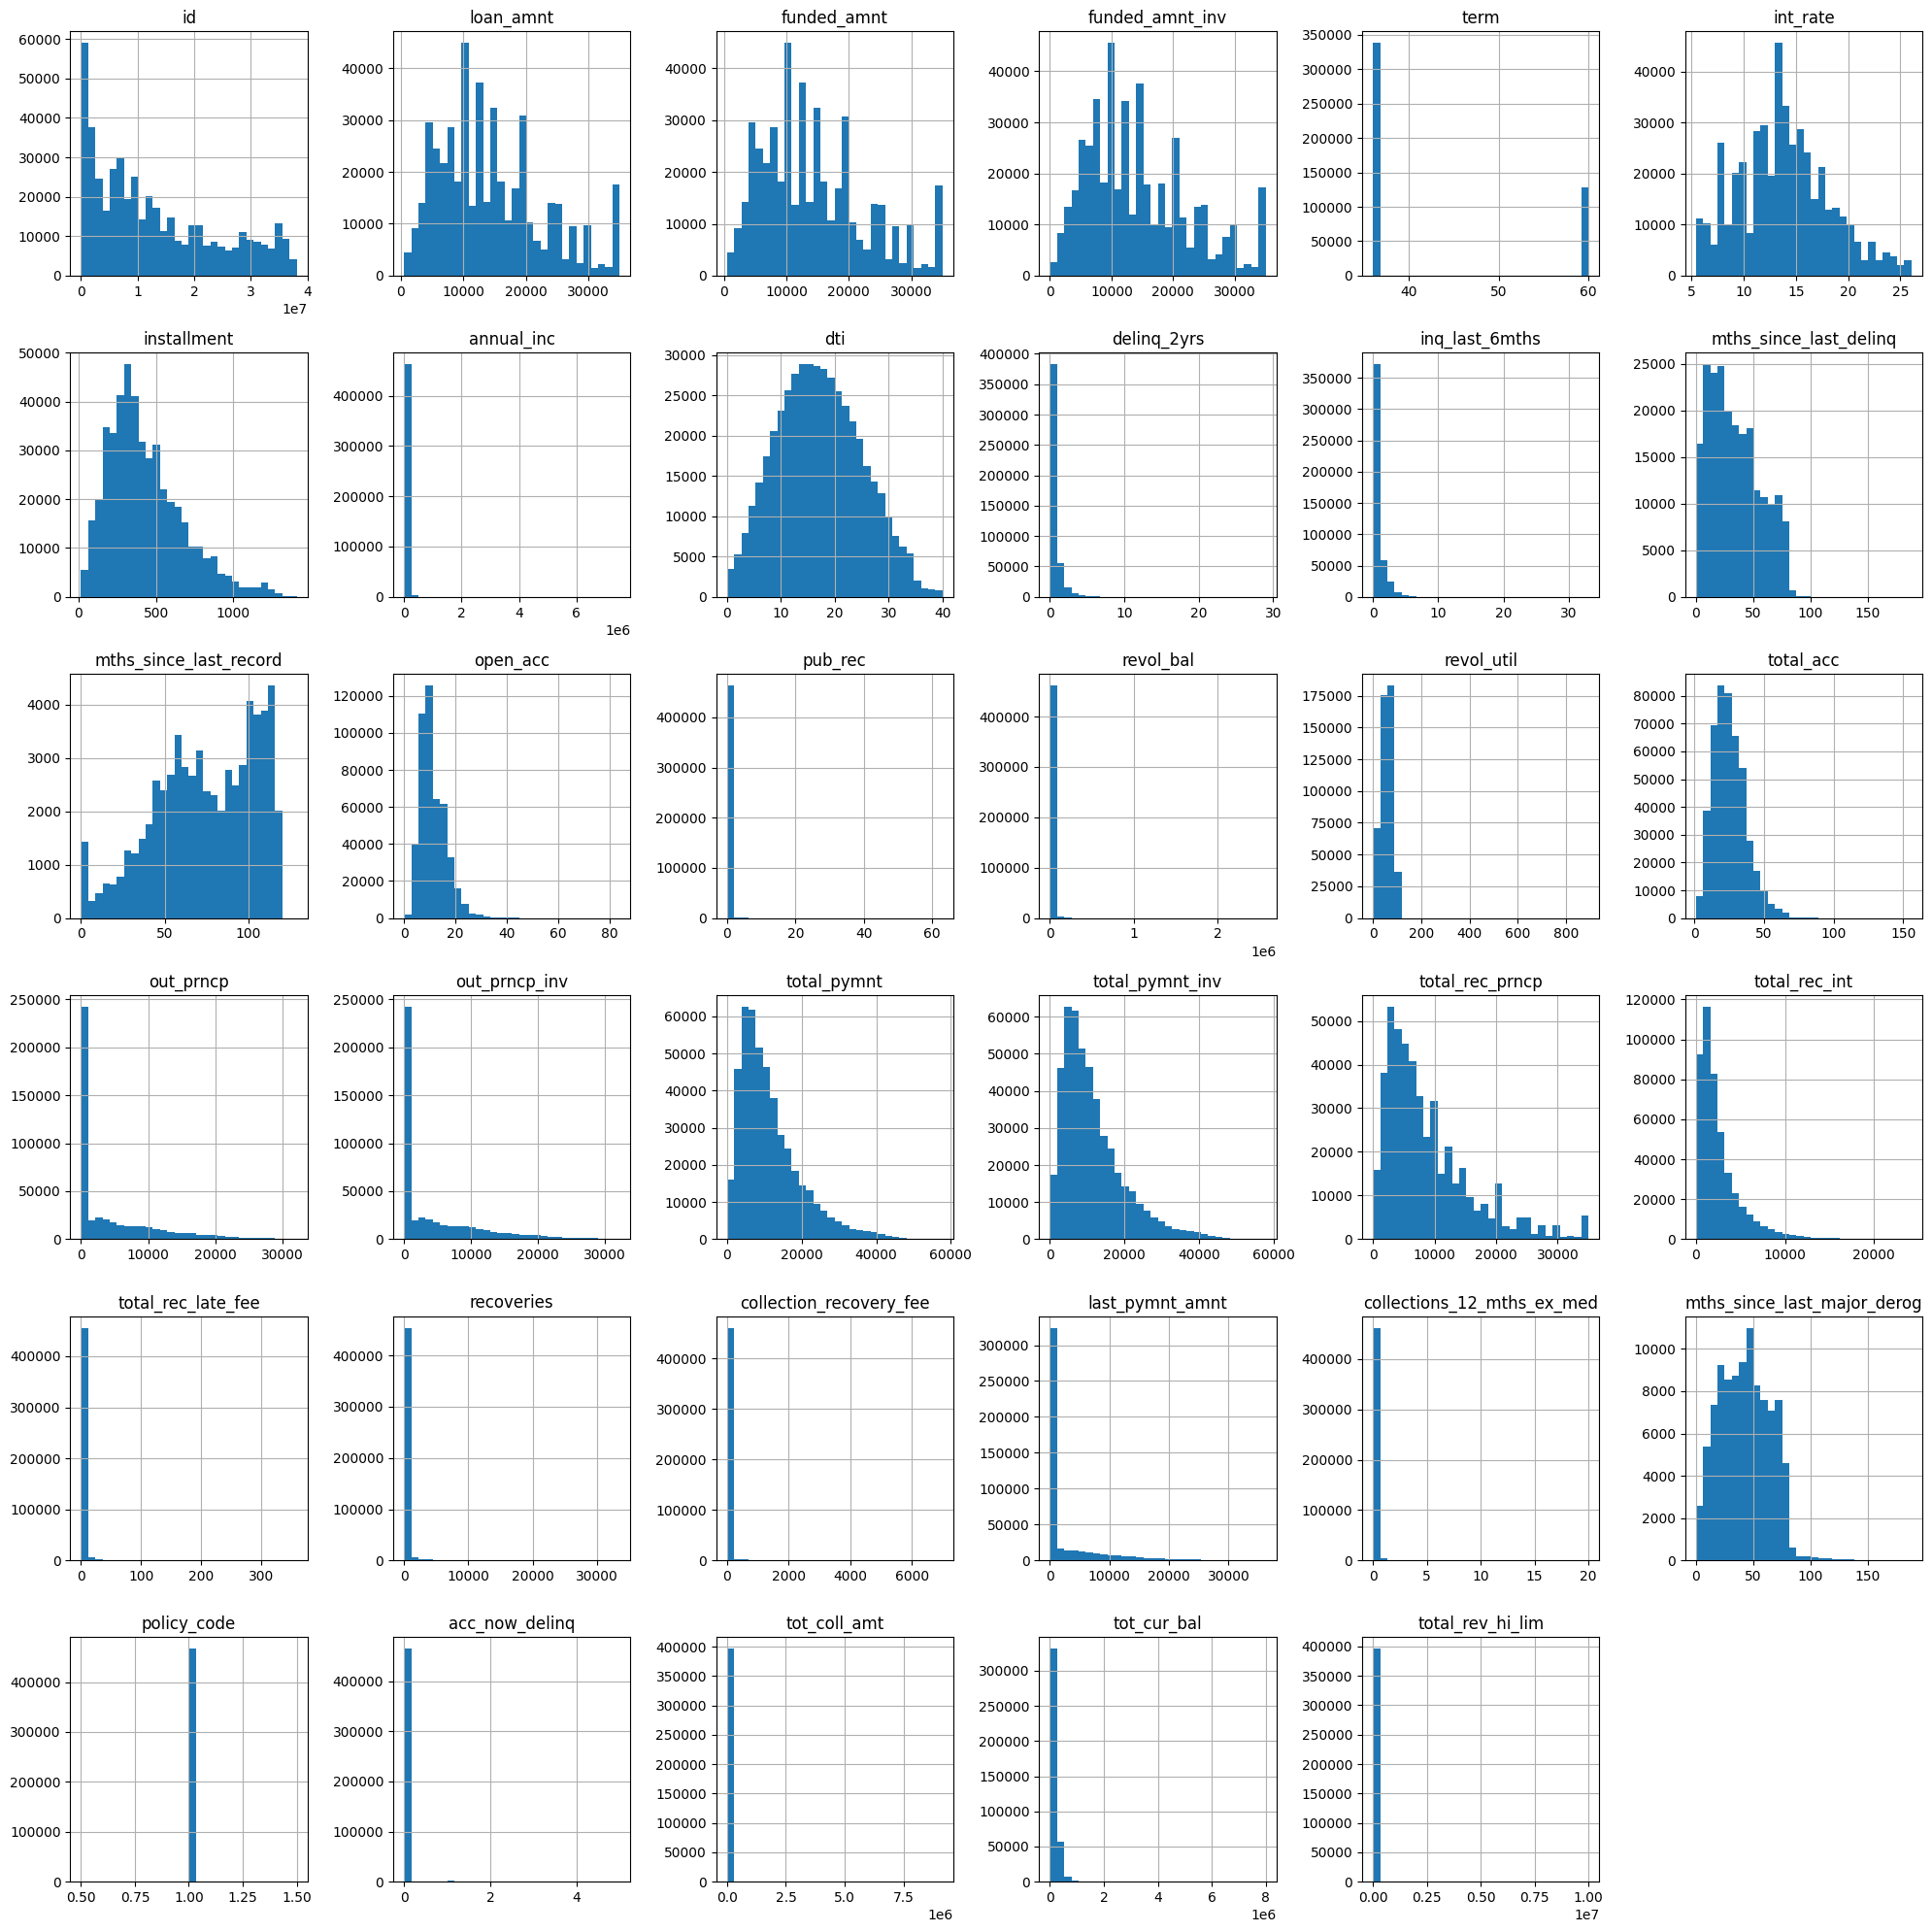

In [ ]:
# mengamati distribusi kolom numerik pada dataset
df[num_cols].hist(bins=30, figsize=(20,20))
plt.tight_layout()
plt.show()



*   Hampir seluruh kolom numerik pada dataset memiliki distribusi skewed serta memiliki rentang nilai (range) yang sangat panjang. Hal ini menandakan bahwa data tersebut memiliki outlier
*   Kolom loan_amnt, funded_amnt, dan funded_amnt_inv memiliki distribusi data yang sama persis
*   Kolom total_amnt dan total_amnt_inv memiliki distribusi yang sama persis





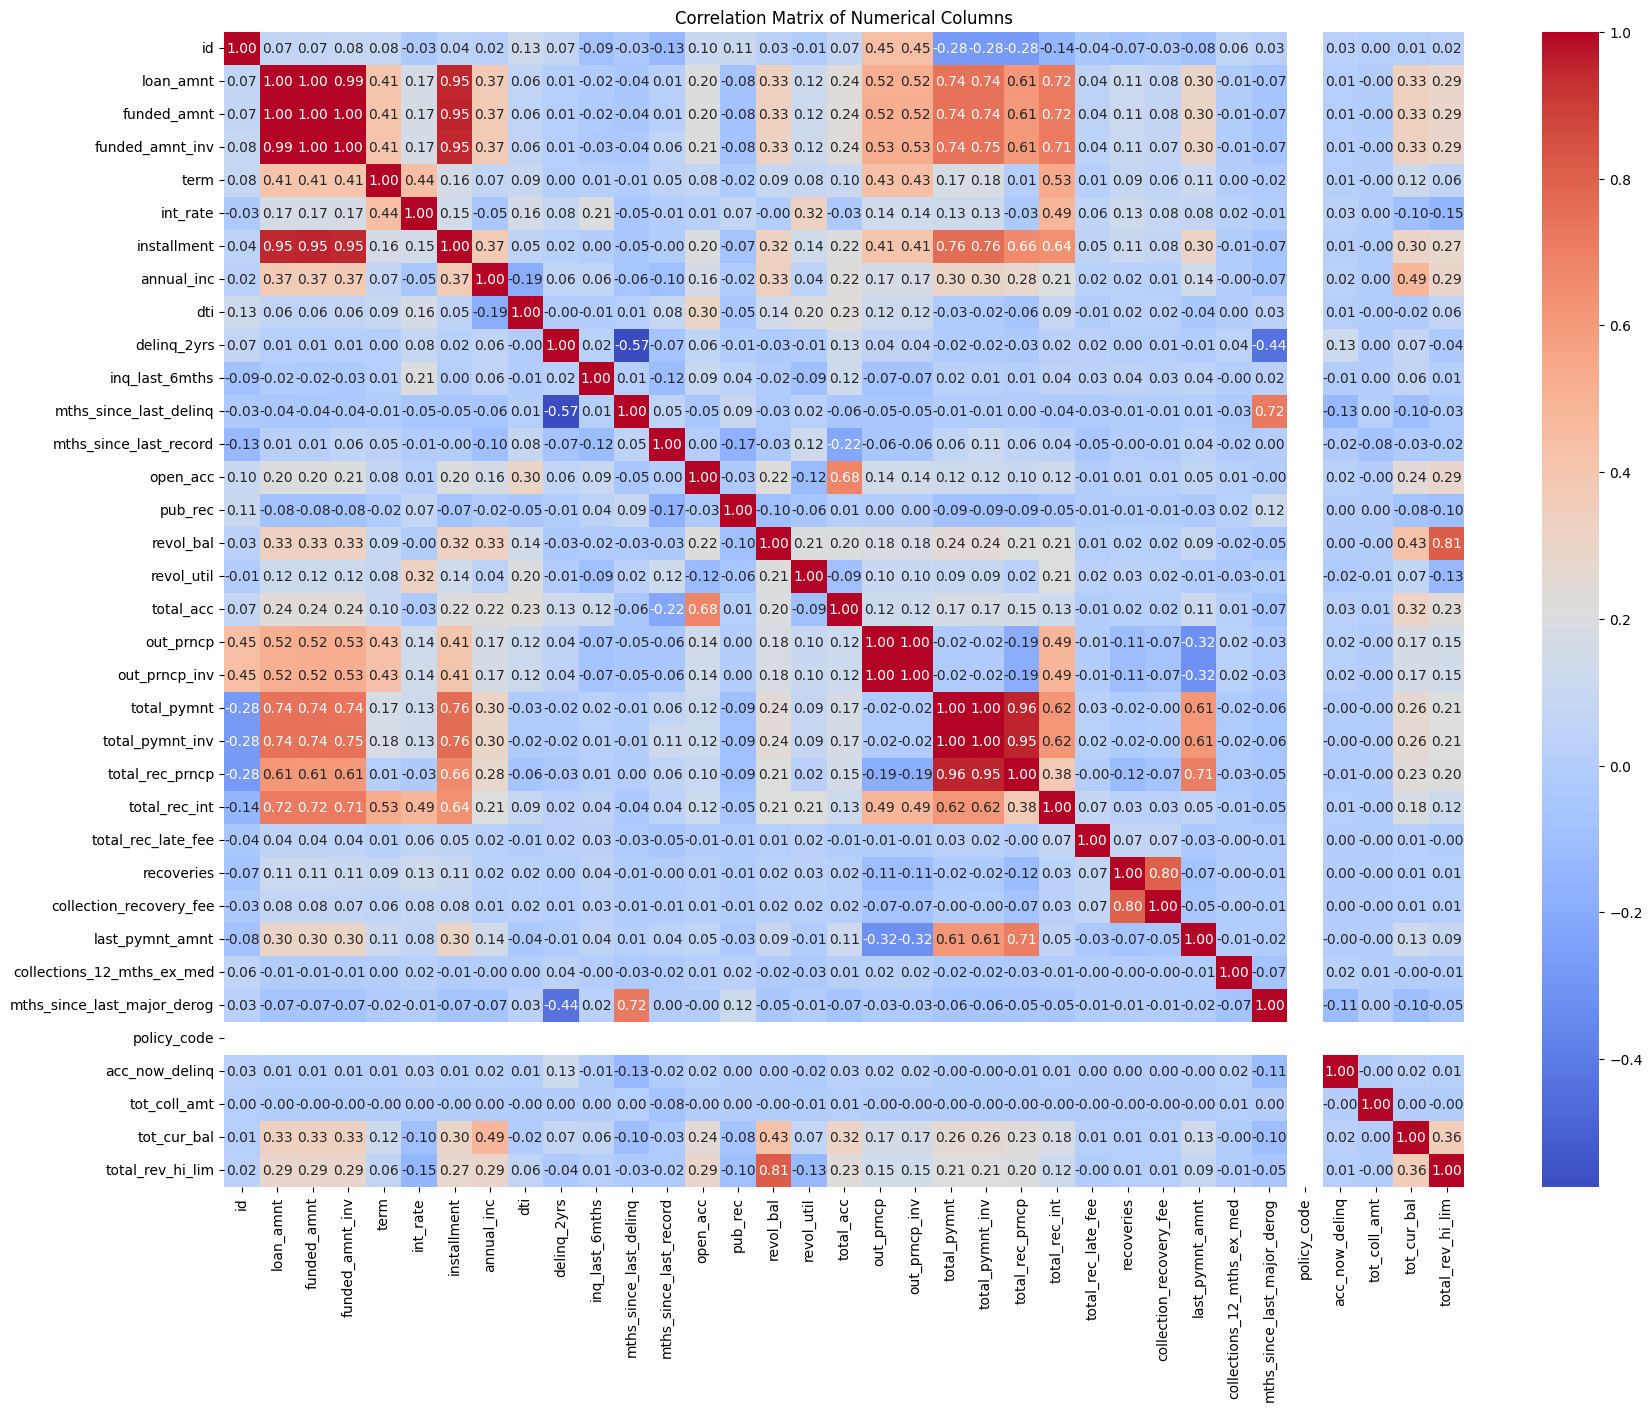

In [ ]:
# mengamati nilai korelasi pada setiap kolom numerik
plt.figure(figsize=(20, 15))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Columns')
plt.show()



*   loan_amnt, funded_amnt, dan funded_amnt_inv berkorelasi positif sangat tinggi (0.99-1.00) yang menandakan bahwa jumlah kredit yang diajukan seluruh debitur bernilai sama dengan yang diberikan kreditur, baik dari investor maupun bukan. Hal ini merupakan multikolinearitas
*   performa kredit seperti total_pymnt dengan total_rec_prncp, out_prncp dengan out_prncp_inv, dan total_rec_prncp dengan total_pymnt_inv juga saling berkorelasi tinggi (0.95-1.00) yang juga mengindikasikan multikolinearitas
*   Saldo rekening (tot_cur_bal) berkorelasi positif dengan pendapatan (annual_inc sekitar 0.49) dan total/limit kredit (revol_bal sekitar 0.43 dan total_rev_hi_lim sekitar 0.39). Semakin besar pendapatan maka besar kemungkinan semakin besar pula kreditnya.
*   Jumlah akun kredit (total_acc) yang tinggi kemungkinan besar memiliki total akun aktif (open_acc) yang tinggi pula
*   Nasabah yang memiliki jumlah bulan keterlambatan (mnth_since_last_delinq) yang kecil kemungkinan besar juga tidak telat bayar lebih dari 90 hari (mths_since_last_derog) namun memiliki jumlah keterlambatan 30 hari (delinq_2yrs) yang lebih besar










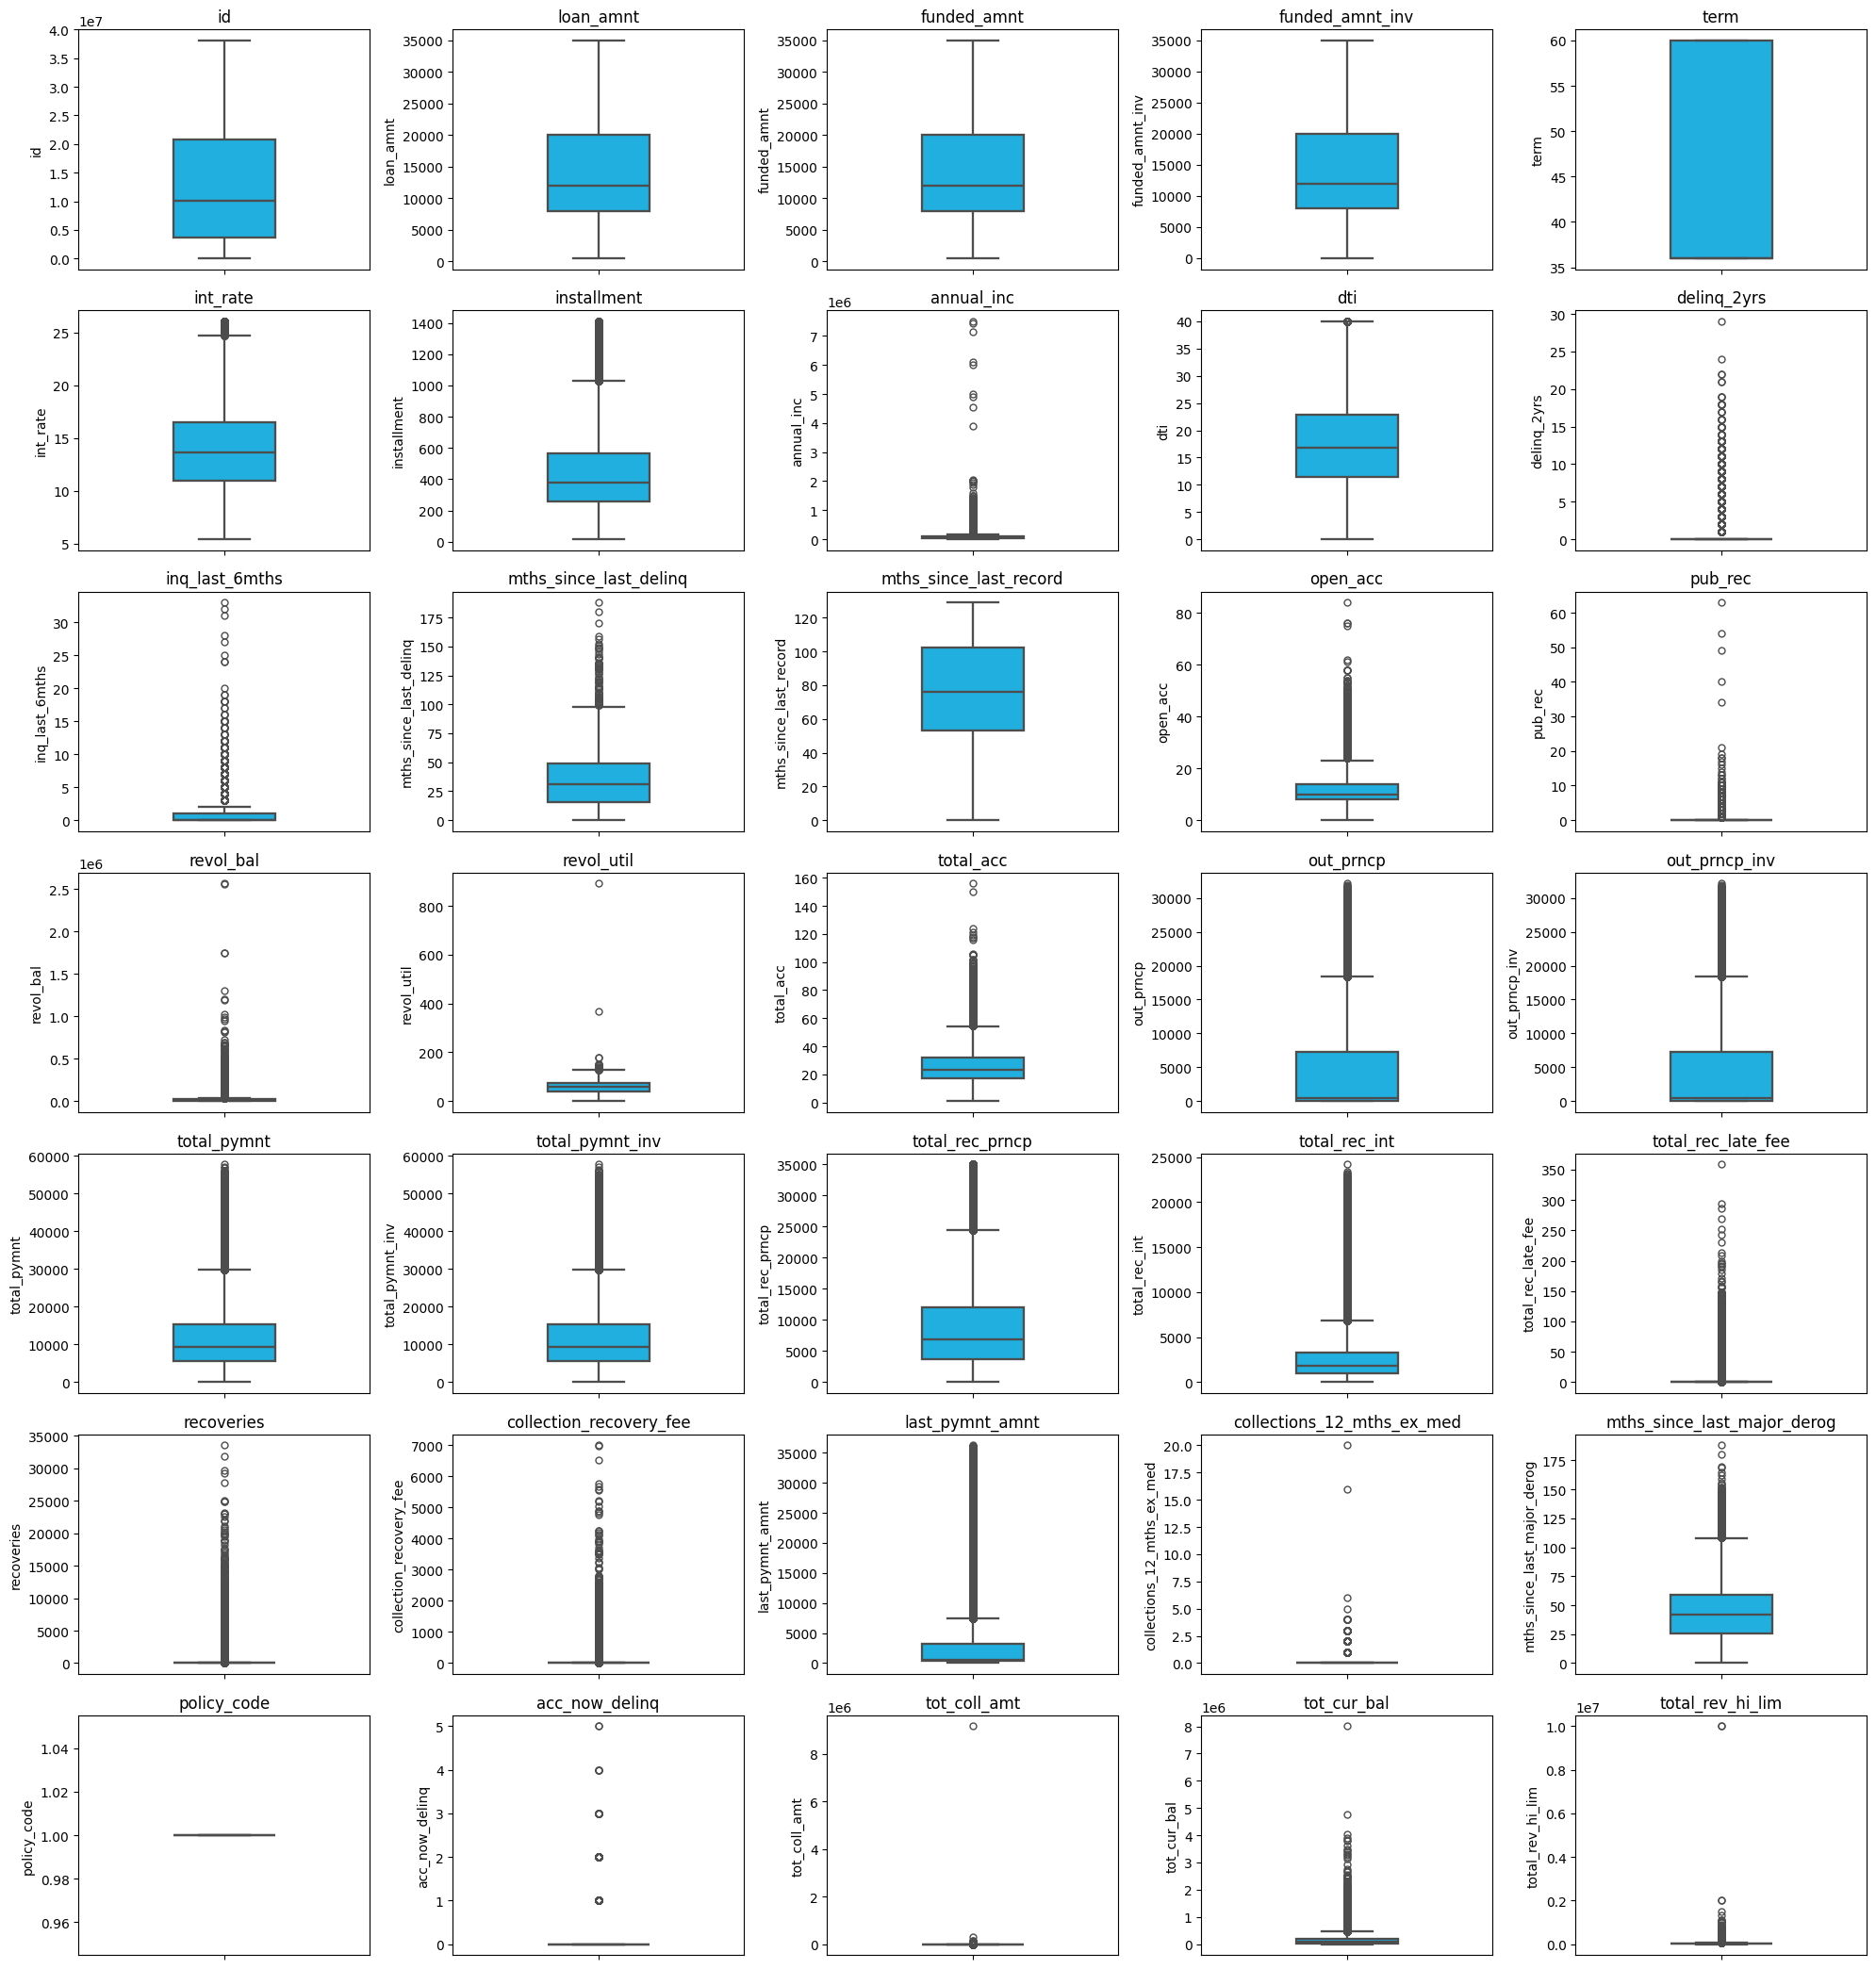

In [ ]:
# mengamati outlier pada dataset numerik dengan menggunakan boxplot
import math

plots_per_row = 5
num_rows = math.ceil(len(num_cols) / plots_per_row)

numeric_filtered = df[num_cols]

plt.figure(figsize=(plots_per_row * 4, num_rows * 3))

for i, col in enumerate(numeric_filtered.columns, 1):
    plt.subplot(num_rows, plots_per_row, i)
    sns.boxplot(y=numeric_filtered[col], width=0.35, color="deepskyblue", linewidth=1.65, fliersize=5)
    plt.title(col)
    plt.tight_layout()
plt.show()

In [ ]:
# daftar kolom yang bertipe string
print(f"Jumlah kolom kategorikal: {len(cat_cols)}")
cat_cols.unique()

Jumlah kolom kategorikal: 21


Index(['grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url',
       'desc', 'purpose', 'title', 'zip_code', 'addr_state',
       'earliest_cr_line', 'initial_list_status', 'last_pymnt_d',
       'next_pymnt_d', 'last_credit_pull_d', 'application_type'],
      dtype='object')

In [ ]:
# jumlah value pada setiap kolom kategorikal
for cols in cat_cols:
  print(df[cols].value_counts())

grade
B    136929
C    125293
D     76888
A     74867
E     35757
F     13229
G      3322
Name: count, dtype: int64
sub_grade
B3    31686
B4    30505
C1    26953
C2    26740
B2    26610
C3    25317
B5    25252
C4    24105
B1    22876
C5    22178
A5    21757
D1    19261
A4    19045
D2    17046
D3    14916
D4    14099
A3    12568
D5    11566
A2    10956
A1    10541
E1     9033
E2     8669
E3     6976
E4     5992
E5     5087
F1     3940
F2     3001
F3     2708
F4     2067
F5     1513
G1     1109
G2      823
G3      583
G4      422
G5      385
Name: count, dtype: int64
emp_title
Teacher                                 5399
Manager                                 4438
Registered Nurse                        2316
RN                                      2204
Supervisor                              1967
                                        ... 
berenfield  containers                     1
harris rebar                               1
sierra vista regional medical center       1
County of San

In [ ]:
# jumlah masing-masing value pada kolom target
df['loan_status'].value_counts()

,count
loan_status,
current,224226
fully_paid,184739
charged_off,42475
late_(31-120_days),6900
in_grace_period,3146
does_not_meet_the_credit_policy._status:fully_paid,1988
late_(16-30_days),1218
default,832
does_not_meet_the_credit_policy._status:charged_off,761


**Mendefinisikan Low risk dan High Risk**

In [ ]:
# mengelompokkan kategori loan status yang bersifat low risk dan high risk
low_risk = ['fully_paid', 'does_not_meet_the_credit_policy._status:fully_paid']
high_risk = ['charged_off', 'default', 'does_not_meet_the_credit_policy._status:charged_off']

# membuat dataset baru
df_prep = df.copy()

# membuat kolom baru yang berisikan dua kelompok risiko
df_prep = df_prep[df_prep['loan_status'].isin(low_risk + high_risk)]
df_prep['risk'] = df_prep['loan_status'].apply(lambda x: 1 if x in low_risk else 0)
df_prep['risk'] = df_prep['risk'].replace({1: 'low_risk', 0: 'high_risk'})

df_prep[['loan_status', 'risk']].head(15)

,loan_status,risk
0,fully_paid,low_risk
1,charged_off,high_risk
2,fully_paid,low_risk
3,fully_paid,low_risk
5,fully_paid,low_risk
7,fully_paid,low_risk
8,charged_off,high_risk
9,charged_off,high_risk
10,fully_paid,low_risk
11,fully_paid,low_risk


In [ ]:
df_prep['risk'].value_counts()

,count
risk,
low_risk,186727
high_risk,44068


**Membuat Tabel Vintage, Cohort, dan Visualisasinya**

/tmp/ipython-input-435/2350729717.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_prep['issue_d'] = pd.to_datetime(df_prep['issue_d'])
/tmp/ipython-input-435/2350729717.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_prep['last_pymnt_d'] = pd.to_datetime(df_prep['last_pymnt_d'])


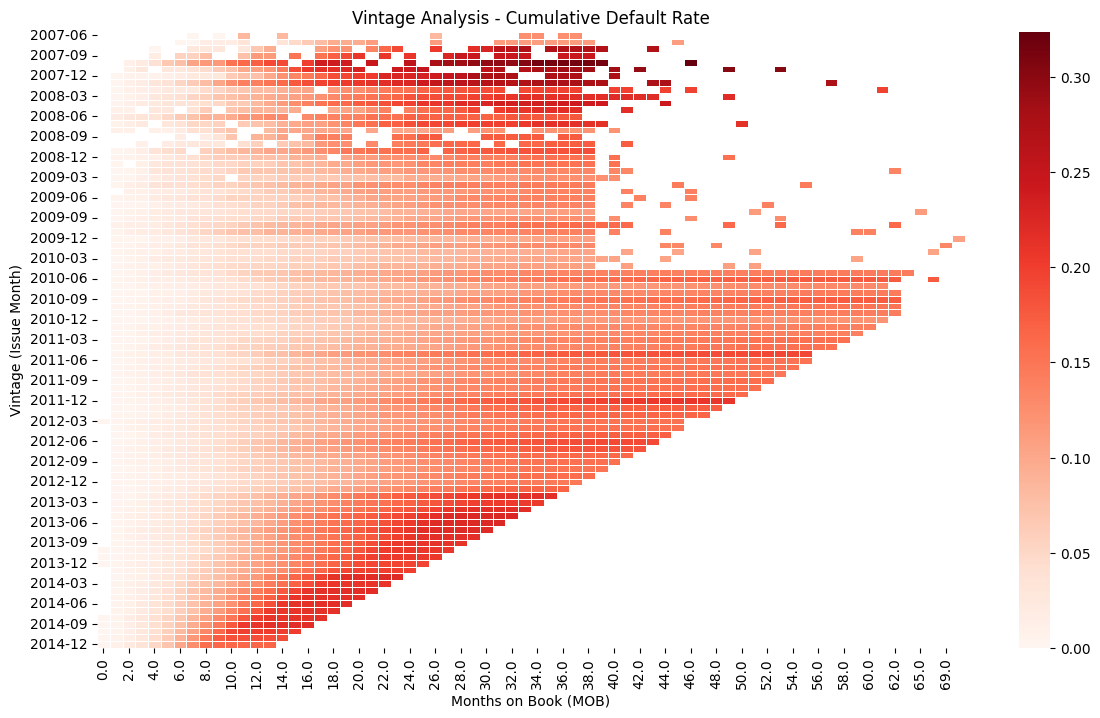

In [ ]:
df_prep['issue_d'] = pd.to_datetime(df_prep['issue_d'])
df_prep['last_pymnt_d'] = pd.to_datetime(df_prep['last_pymnt_d'])

# Membuat kolom month on book (MOB), yaitu selisih bulan antara issue_d dan last_pymnt_d
df_prep['mob'] = (
    (df_prep['last_pymnt_d'].dt.year - df_prep['issue_d'].dt.year) * 12 +
    (df_prep['last_pymnt_d'].dt.month - df_prep['issue_d'].dt.month)
)

# Menggunakan MOB yang selisihnya mulai dari 0 bulan
df_prep = df_prep[df_prep['mob'] >= 0]

# Membuat kolom vintage yang diambil dari issue_d
df_prep['vintage'] = df_prep['issue_d'].dt.to_period('M')

# Memberi flag 1 untuk high risk dan 0 untuk low risk (digunakan untuk cohort)
df_prep['high_risk_flag'] = (df_prep['risk'] == 'high_risk').astype(int)

# Membuat tabel cohort
cohort = (
    df_prep
    .groupby(['vintage', 'mob'])
    .agg(
        total_loans=('high_risk_flag','count'),
        defaults=('high_risk_flag','sum')
    )
    .reset_index()
)

# Membuat tabel yang berisikan jumlah flag 1 dan 0 untuk setiap bulan
vintage_size = (
    df_prep
    .groupby('vintage')
    .agg(vintage_total=('high_risk_flag','count'))
    .reset_index()
)

# Merge cohort dengan vintage_size
cohort = cohort.merge(vintage_size, on='vintage')

# Membuat kolong untuk menghitung kumulatif default
cohort['cumulative_defaults'] = (
    cohort
    .groupby('vintage')['defaults']
    .cumsum()
)

cohort['cumulative_default_rate'] = (
    cohort['cumulative_defaults'] / cohort['vintage_total']
)

# Pivot table cohort (index menggunakan vintage dan kolom menggunakan MOB)
cohort_matrix = cohort.pivot(
    index='vintage',
    columns='mob',
    values='cumulative_default_rate'
)

# membuat visualisasi tabel
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))
sns.heatmap(cohort_matrix,
            cmap='Reds',
            linewidths=0.5)

plt.title('Vintage Analysis - Cumulative Default Rate')
plt.ylabel('Vintage (Issue Month)')
plt.xlabel('Months on Book (MOB)')
plt.show()

Insights:


*   Terdapat perbedaan yang Month of Book (MOB) yang signifikan pada cohort sebelum 2010 dan setelah 2010. Pada cohort sebelum 2010 nasabah hanya mengambil tenor 36 bulan sedangkan selama 2010 Nasabah tidak hanya mengambil tenor 36 namun juga 60 bulan. Hal ini menunjukkan adanya diversifikasi tenor seperti pada gambar berikut

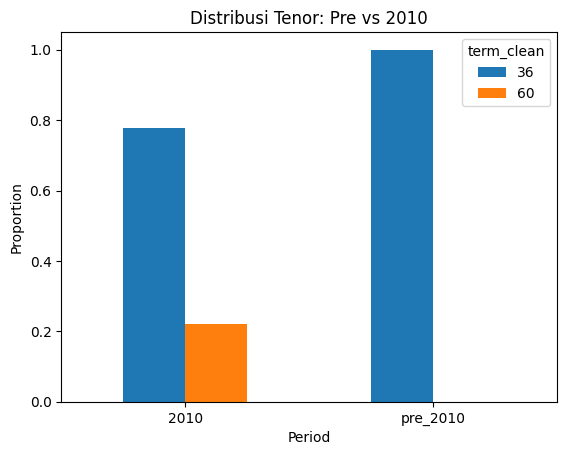




*   Pada Cohort September-Desember 2007 terdapat tingkat kumulatif default (high risk) mencapai 30%. Kenaikan tersebut mulai terjadi pada MOB ke 12. Pada tahun tersebut telah terjadi peristiwa Resesi Global 2008. Pada saat itu harga rumah dan tanah di Amerika sedang mengalami kenaikan pesat sehingga penduduk setempat berbondong-bondong segera membeli rumah dengan menggunakan kredit walaupun tidak memiliki pendapatan tetap sehingga berpotensi melonjaknya jumlah gagal bayar pada saat itu. Sehingga pada tahap ini dataset kemudian akan dilakukan uji hipotesis apakah terdapat perbedaan yang signifikan pengambilan kredit untuk kepemilikan rumah antara sebelum krisis (2008-2009) dan setelah krisis (2009-seterusnya)




**Uji Hipotesis**



*   H0 : Tidak terdapat perbedaan signifikan KPR saat dan setelah Krisis Global 2008
*   H1 : Terdapat perbedaan signifikan KPR saat dan setelah Krisis Global 2008



In [ ]:
from statsmodels.stats.proportion import proportions_ztest

df_prep['issue_year'] = df_prep['issue_d'].dt.year

# membuat dataset baru untuk house
df_house = df_prep[df_prep['purpose'].isin(['home_improvement','house'])]

# definisi periode
df_house['period'] = df_house['issue_year'].apply(
    lambda x: 'crisis' if x in [2008,2009] else 'post' if x >= 2010 else 'other'
)

df_house = df_house[df_house['period'].isin(['crisis','post'])]

# hitung jumlah
summary = df_house.groupby('period')['high_risk_flag'].agg(['sum','count'])

defaults = summary['sum'].values
nobs = summary['count'].values

# uji hipotesis dengn Z-Test
stat, pval = proportions_ztest(defaults, nobs)

stat, pval

/tmp/ipython-input-435/737232443.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_house['period'] = df_house['issue_year'].apply(


(np.float64(-1.0033570393620066), np.float64(0.31568862430515454))

In [ ]:
# Total kredit dan jumlah default pada dua periode
summary

,sum,count
period,,
crisis,94,622
post,2371,14248


In [ ]:
# menetapkan signifikansi sebesar 0.05
alpha = 0.05

print("Hasil uji hipotesis dengan Z-Test:")
print()
print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {pval:.4f}")

if pval < alpha:
    print("Tolak H₀ → Ada perbedaan signifikan antara periode crisis dan post")
else:
    print("Gagal tolak H₀ → Tidak ada perbedaan signifikan")

Hasil uji hipotesis dengan Z-Test:

Z-statistic: -1.0034
P-value: 0.3157
Gagal tolak H₀ → Tidak ada perbedaan signifikan


**Uji Hipotesis dengan Chi-Square**

In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df_house['period'], df_house['high_risk_flag'])

chi2, p, dof, exp = chi2_contingency(table)

p

np.float64(0.3429860828481528)

In [ ]:
print("Hasil uji hipotesis dengan Z-Test:")
print()

if p < 0.05:
    print("Tolak H₀ → Ada hubungan signifikan antara period dan high_risk_flag")
else:
    print("Gagal tolak H₀ → Tidak ada hubungan signifikan")

Hasil uji hipotesis dengan Z-Test:

Gagal tolak H₀ → Tidak ada hubungan signifikan




*   Setelah dilakukan uji hipotesis dengan menggunakan z-test dan chi square, ditemukan bahwa tidak terdapat perbedaan signifikan antara periode sebelum dan pasca krisis (z-test) dan tidak terdapat asosiasi antara periode krisis dengan risiko default untuk kredit kepemilikan rumah




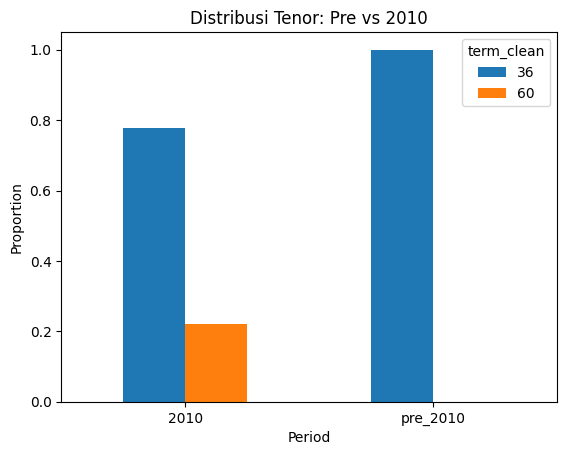

In [ ]:
# Mengamati distribusi tenor yang dipilih untuk sebelum tahun 2010 dan setelahnya

df_prep['term_clean'] = (
    df_prep['term']
    .astype(int)
)

df_prep['issue_year'] = df_prep['issue_d'].dt.year

df_prep['period'] = df_prep['issue_year'].apply(
    lambda x: 'pre_2010' if x < 2010 else '2010'
)

tenor_distribution = pd.crosstab(
    df_prep['period'],
    df_prep['term_clean'],
    normalize='index'
)

tenor_distribution

import matplotlib.pyplot as plt

tenor_distribution.plot(kind='bar')
plt.title('Distribusi Tenor: Pre vs 2010')
plt.ylabel('Proportion')
plt.xlabel('Period')
plt.xticks(rotation=0)
plt.show()

**Data Preparation untuk Modelling**

Dalam melakukan prediksi risiko kredit beberapa fitur performa pinjaman seperti total_pymnt, last_pymnt_amnt, dan recoveries tidak dapat digunakan karena fitur tersebut menggambarkan performa terakhir dari pinjaman (risk flag) yang telah diberikan, sehingga model berpotensi mengalami leakage.

**Feature Selection**

In [ ]:
# membuat dataset baru yang akan digunakan untuk tahap modelling
df_prep_mod = df_prep[['id', 'funded_amnt', 'term', 'int_rate',
                       'installment', 'grade', 'emp_length', 'home_ownership',
                       'annual_inc', 'verification_status', 'purpose', 'dti',
                       'loan_status', 'risk', 'high_risk_flag', 'open_acc',
                       'total_acc', 'pub_rec', 'delinq_2yrs', 'inq_last_6mths',
                       'revol_bal', 'revol_util'
                       ]]
df_prep_mod.head()

,id,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,...,loan_status,risk,high_risk_flag,open_acc,total_acc,pub_rec,delinq_2yrs,inq_last_6mths,revol_bal,revol_util
0,1077501,5000,36,10.65,162.87,B,10+ years,rent,24000.0,verified,...,fully_paid,low_risk,0,3.0,9.0,0.0,0.0,1.0,13648,83.7
1,1077430,2500,60,15.27,59.83,C,< 1 year,rent,30000.0,source_verified,...,charged_off,high_risk,1,3.0,4.0,0.0,0.0,5.0,1687,9.4
2,1077175,2400,36,15.96,84.33,C,10+ years,rent,12252.0,not_verified,...,fully_paid,low_risk,0,2.0,10.0,0.0,0.0,2.0,2956,98.5
3,1076863,10000,36,13.49,339.31,C,10+ years,rent,49200.0,source_verified,...,fully_paid,low_risk,0,10.0,37.0,0.0,0.0,1.0,5598,21.0
5,1075269,5000,36,7.90,156.46,A,3 years,rent,36000.0,source_verified,...,fully_paid,low_risk,0,9.0,12.0,0.0,0.0,3.0,7963,28.3


In [ ]:
# membuat kolom baru yang menghitung perkalian antara installment dan term
df_prep_mod['total']=None
df_prep_mod['total'] = df_prep_mod['installment'] * df_prep_mod['term']
df_prep_mod.head(10)

/tmp/ipython-input-435/1994641722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prep_mod['total']=None
/tmp/ipython-input-435/1994641722.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prep_mod['total'] = df_prep_mod['installment'] * df_prep_mod['term']


,id,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,...,risk,high_risk_flag,open_acc,total_acc,pub_rec,delinq_2yrs,inq_last_6mths,revol_bal,revol_util,total
0,1077501,5000,36,10.65,162.87,B,10+ years,rent,24000.0,verified,...,low_risk,0,3.0,9.0,0.0,0.0,1.0,13648,83.7,5863.32
1,1077430,2500,60,15.27,59.83,C,< 1 year,rent,30000.0,source_verified,...,high_risk,1,3.0,4.0,0.0,0.0,5.0,1687,9.4,3589.80
2,1077175,2400,36,15.96,84.33,C,10+ years,rent,12252.0,not_verified,...,low_risk,0,2.0,10.0,0.0,0.0,2.0,2956,98.5,3035.88
3,1076863,10000,36,13.49,339.31,C,10+ years,rent,49200.0,source_verified,...,low_risk,0,10.0,37.0,0.0,0.0,1.0,5598,21.0,12215.16
5,1075269,5000,36,7.90,156.46,A,3 years,rent,36000.0,source_verified,...,low_risk,0,9.0,12.0,0.0,0.0,3.0,7963,28.3,5632.56
7,1072053,3000,36,18.64,109.43,E,9 years,rent,48000.0,source_verified,...,low_risk,0,4.0,4.0,0.0,0.0,2.0,8221,87.5,3939.48
8,1071795,5600,60,21.28,152.39,F,4 years,own,40000.0,source_verified,...,high_risk,1,11.0,13.0,0.0,0.0,2.0,5210,32.6,9143.40
9,1071570,5375,60,12.69,121.45,B,< 1 year,rent,15000.0,verified,...,high_risk,1,2.0,3.0,0.0,0.0,0.0,9279,36.5,7287.00
10,1070078,6500,60,14.65,153.45,C,5 years,own,72000.0,not_verified,...,low_risk,0,14.0,23.0,0.0,0.0,2.0,4032,20.6,9207.00
11,1069908,12000,36,12.69,402.54,B,10+ years,own,75000.0,source_verified,...,low_risk,0,12.0,34.0,0.0,0.0,0.0,23336,67.1,14491.44


In [ ]:
df_prep_mod.shape

(230419, 23)

In [ ]:
# memeriksa value yang unique, duplikat dan null
print('duplicate value:', df_prep_mod.duplicated().sum())
print()
print('null value:')
print(df_prep_mod.isnull().sum())
print()
print('unique value:')
print(df_prep_mod.nunique())

duplicate value: 0

null value:
id                        0
funded_amnt               0
term                      0
int_rate                  0
installment               0
grade                     0
emp_length             8733
home_ownership            0
annual_inc                4
verification_status       0
purpose                   0
dti                       0
loan_status               0
risk                      0
high_risk_flag            0
open_acc                 29
total_acc                29
pub_rec                  29
delinq_2yrs              29
inq_last_6mths           29
revol_bal                 0
revol_util              220
total                     0
dtype: int64

unique value:
id                     230419
funded_amnt              1311
term                        2
int_rate                  505
installment             43032
grade                       7
emp_length                 11
home_ownership              6
annual_inc              18176
verification_status       

In [ ]:
print(df_prep_mod['emp_length'].value_counts())
print('null value:', df_prep_mod['emp_length'].isnull().sum())

emp_length
10+ years    68681
2 years      21603
< 1 year     19285
3 years      18730
5 years      16784
1 year       15544
4 years      14911
6 years      13822
7 years      13013
8 years      10684
9 years       8629
Name: count, dtype: int64
null value: 8733


In [ ]:
# mentransformasi fitur emp_length menjadi numerik
def clean_emp_length(emp_len):
    if pd.isna(emp_len): # Handle NaN values
        return 0
    if '10+' in emp_len:
        return 10
    if '< 1' in emp_len:
        return 0
    return int(emp_len.replace(' years', '').replace(' year', ''))

df_prep_mod['emp_length'] = df_prep_mod['emp_length'].apply(clean_emp_length).astype(int)

# mengisi null value dengan 0
df_prep_mod.fillna(0, inplace=True)

/tmp/ipython-input-435/201774958.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prep_mod['emp_length'] = df_prep_mod['emp_length'].apply(clean_emp_length).astype(int)
/tmp/ipython-input-435/201774958.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prep_mod.fillna(0, inplace=True)


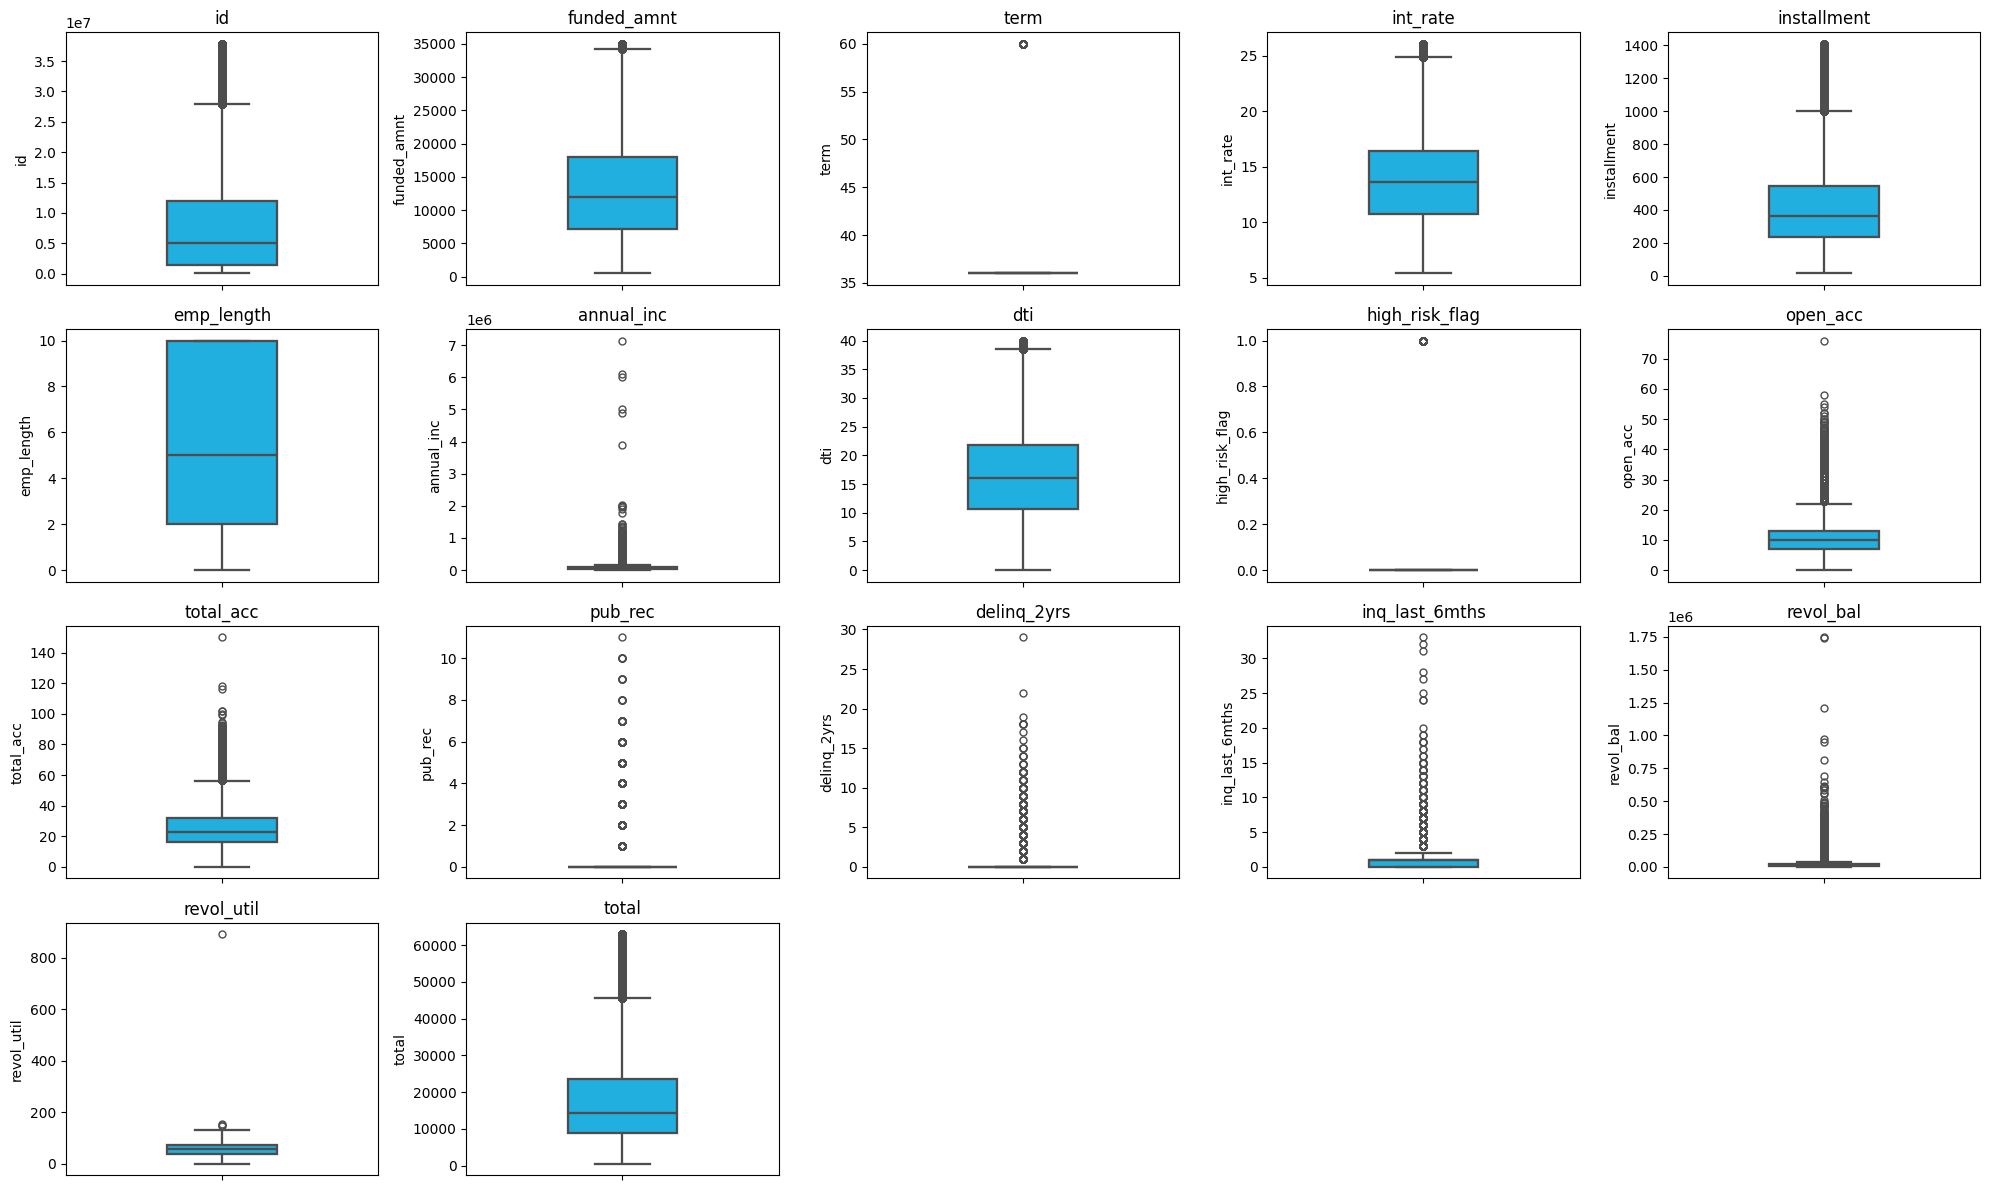

In [ ]:
import math

numeric_cols_mod = df_prep_mod.select_dtypes(include=['int64','float64']).columns
plots_per_row = 5
num_rows = math.ceil(len(numeric_cols_mod) / plots_per_row)

plt.figure(figsize=(plots_per_row * 4, num_rows * 3))

for i, col in enumerate(numeric_cols_mod, 1):
    plt.subplot(num_rows, plots_per_row, i)
    sns.boxplot(y=df_prep_mod[col], width=0.35, color="deepskyblue", linewidth=1.65, fliersize=5)
    plt.title(col)
plt.tight_layout()
plt.show()

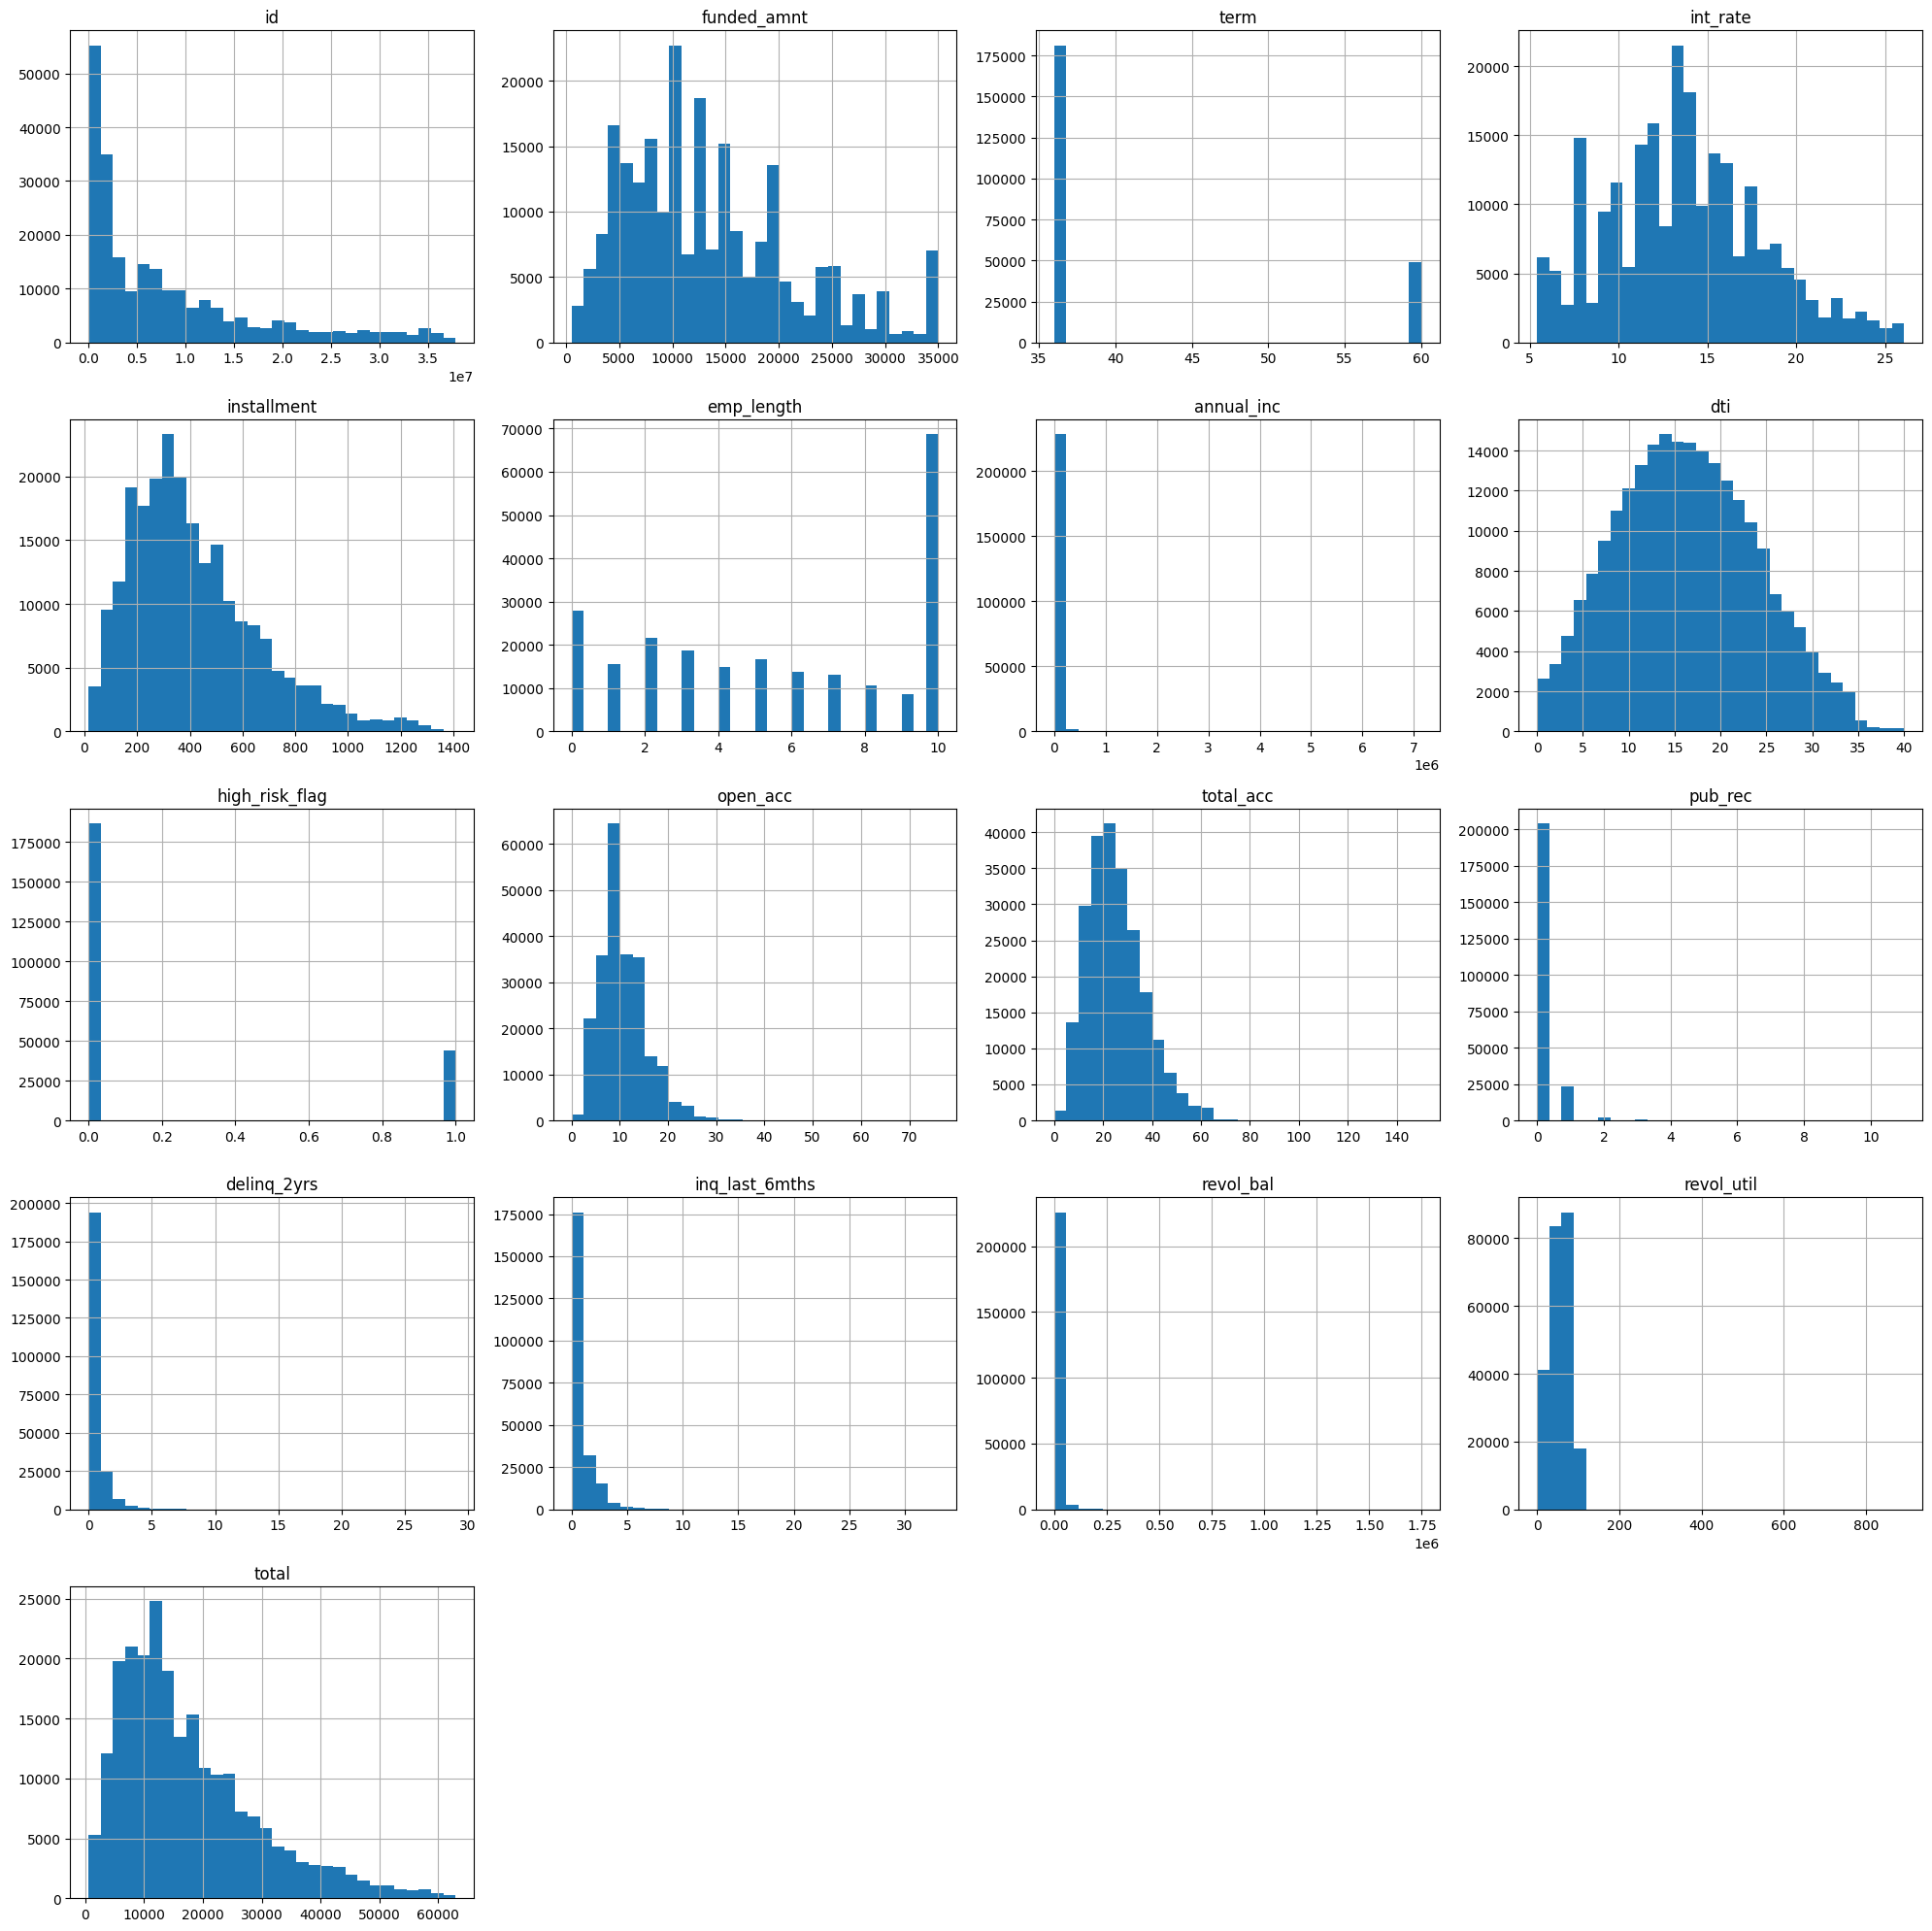

In [ ]:
df_prep_mod[numeric_cols_mod].hist(bins=30, figsize=(20,20))
plt.tight_layout()
plt.show()

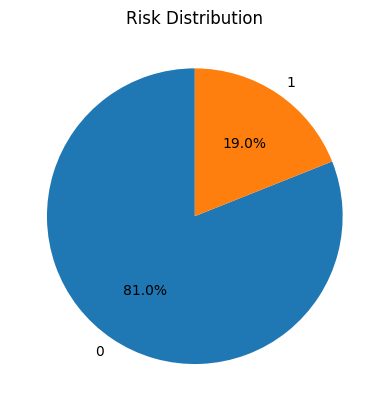

In [ ]:
# Mengamati distribusi fitur target
count = df_prep_mod['high_risk_flag'].value_counts()
labels = [0, 1]

plt.pie(count, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Risk Distribution')
plt.show()

In [ ]:
print(df_prep_mod['high_risk_flag'].value_counts())

high_risk_flag
0    186727
1     43692
Name: count, dtype: int64


**Feature Engineering**

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

# Mengelompokkan fitur-fitur yang akan digunakan
num_features = ['funded_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
                'open_acc', 'total_acc', 'pub_rec', 'delinq_2yrs', 'inq_last_6mths',
                'revol_bal', 'revol_util']
cat_ord_features = ['grade', 'emp_length']
cat_one_features = ['term', 'home_ownership', 'verification_status', 'purpose']

In [ ]:
# Transformasi fitur
preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaler', MinMaxScaler(), num_features),
        ('cat_encoder', OneHotEncoder(), cat_one_features),
        ('cat_ord_encoder', OrdinalEncoder(), cat_ord_features)
    ],
    remainder='drop'
)

df_fin_prep = preprocessor.fit_transform(df_prep_mod)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# menentukan variabel dependen (y) dan variabel independen (x)
x = df_fin_prep
y = df_prep_mod['high_risk_flag']

# split data train dan data test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

**Inisiasi Model**

In [ ]:
log_reg = LogisticRegression()

In [ ]:
# melatih model pada data train
log_reg.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

**Evaluasi Model**

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# melakukan prediksi pada data test
y_pred = log_reg.predict(x_test)

# Evaluasi model pada data test dengan confusion matrix
print("Model Evaluation on Original Test Set:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Evaluasi model dengan accuracy, precision, recall, dan F1 score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test,y_pred))

Model Evaluation on Original Test Set:

Confusion Matrix:
[[55324   678]
 [12430   694]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.99      0.89     56002
           1       0.51      0.05      0.10     13124

    accuracy                           0.81     69126
   macro avg       0.66      0.52      0.49     69126
weighted avg       0.76      0.81      0.74     69126


Accuracy Score:
0.8103752567774788


Insight:


*   Model memiliki nilai akurasi yang cukup tinggi, yaitu mencapai 0.81
*   model mampu dapat menebak label 0 dengan akurat sebesar 0.82 dan mendeteksi hampir seluruh label target menjadi 0 (false positive yang tinggi) sebesar 0.99


*   model mampu dapat menebak label 1 dengan akurat sebesar 0.51 dan mendeteksi hampir seluruh label target menjadi 1 (false negative yang tinggi) sebesar 0.05




Pada kasus prediksi risiko kredit, model sebisa mungkin rapat memprediksi seluruh nasabah yang berisiko menerima pinjaman (label 1). Untuk menghindari nasabah berisiko yang lolos dalam prediksi model maka sebaiknya perlu dioptimalkan dengan meningkatkan nilai recall untuk label 1, sehingga metrik inilah yang perlu diperhatikan. Selain itu, akan lebih aman jika model lebih sering salah 'menolak' nasabah berisiko (false positive) padahal bukan daripada memiliki tingkat presisi yang tinggi sehingga akan banyak nasabah yang akan 'diterima' model padahal berisiko.

Skor AUC: 0.6968192412979071


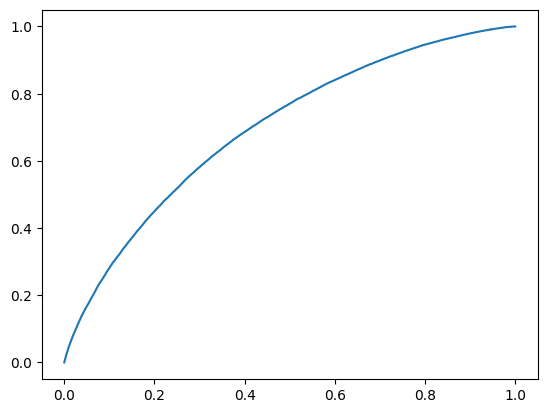

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y, log_reg.predict_proba(x)[:, 1])
plt.plot(fpr, tpr)
print('Skor AUC:', roc_auc_score(y, log_reg.predict_proba(x)[:, 1]))

Nilai recall dapat ditingkatkan dengan melakukan tahapan-tahapan berikut:

**Modelling dengan Cross Validation**

In [ ]:
from sklearn.model_selection import cross_validate

# Melakukan modelling secara berulang pada dataset yang telah dibagi
scores = cross_validate(log_reg, x_train, y_train,
                         scoring=['accuracy', 'precision', 'recall', 'f1'],
                         cv=10,
                         return_train_score=False)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
def print_scores(cv_scores_dict):
    print("Accuracy Mean:", cv_scores_dict['test_accuracy'].mean())
    print("Precision Mean:", cv_scores_dict['test_precision'].mean())
    print("Recall Mean:", cv_scores_dict['test_recall'].mean())
    print("F1 Mean:", cv_scores_dict['test_f1'].mean())
print_scores(scores)

Accuracy Mean: 0.8109775286258571
Precision Mean: 0.5130166463019868
Recall Mean: 0.05289851675067264
F1 Mean: 0.09588814333463921


**Modelling dengan Handling Imbalanced Data (SMOTE)**

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

print("SMOTE resampling completed successfully.")
print("Shape of original training data (X_train):", x_train.shape)
print("Shape of resampled training data (X_train_resampled):", x_train_resampled.shape)
print()
print("Class distribution before SMOTE (y_train):\n", y_train.value_counts())
print()
print("Class distribution after SMOTE (y_train_resampled):\n", y_train_resampled.value_counts())

SMOTE resampling completed successfully.
Shape of original training data (X_train): (161293, 39)
Shape of resampled training data (X_train_resampled): (261450, 39)

Class distribution before SMOTE (y_train):
 high_risk_flag
0    130725
1     30568
Name: count, dtype: int64

Class distribution after SMOTE (y_train_resampled):
 high_risk_flag
0    130725
1    130725
Name: count, dtype: int64


In [ ]:
# inisiasi model dengan data train yang telah diresampled
log_reg_resampled = LogisticRegression()
log_reg_resampled.fit(x_train_resampled, y_train_resampled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Evaluasi model dengan data test yang telah diresampled
y_pred = log_reg_resampled.predict(x_test)

In [ ]:
print("Model Evaluation on Original Test Set:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test,y_pred))

Model Evaluation on Original Test Set:

Confusion Matrix:
[[36803 19199]
 [ 4878  8246]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.75     56002
           1       0.30      0.63      0.41     13124

    accuracy                           0.65     69126
   macro avg       0.59      0.64      0.58     69126
weighted avg       0.77      0.65      0.69     69126


Accuracy Score:
0.6516940080432833


**Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Define compatible parameter grids for LogisticRegression
param_grid = [
    {'penalty': ['l2', None], 'solver': ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag']},
    {'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
    {'penalty': ['l1', 'l2', 'elasticnet', None], 'solver': ['saga']}
]

tuning_logreg = LogisticRegression(max_iter=50)

grid_search = GridSearchCV(tuning_logreg, param_grid, cv=5,
                           scoring=['accuracy', 'precision', 'recall', 'f1'],
                           return_train_score=True,
                           refit='recall')

grid_search.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=50),
             param_grid=[{'penalty': ['l2', None],
                          'solver': ['lbfgs', 'newton-cg', 'newton-cholesky',
                                     'sag']},
                         {'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
                         {'penalty': ['l1', 'l2', 'elasticnet', None],
                          'solver': ['saga']}],
             refit='recall', return_train_score=True,
             scoring=['accuracy', 'precision', 'recall', 'f1'])

In [ ]:
print("Parameter terbaik: ", grid_search.best_params_)
print()
print("Hasil evaluasi recall terbaik: ", grid_search.best_score_)

Parameter terbaik:  {'penalty': 'l1', 'solver': 'liblinear'}

Hasil evaluasi recall terbaik:  0.05682403492270558


In [ ]:
# Mendapatkan kombinasi parameter terbaik dari GridSearch
best_model = grid_search.best_estimator_

# Melakukan prediksi pada dataset tes dengan parameter terbaik
y_pred_best = best_model.predict(x_test)

print("Model Evaluation on Test Set (Best GridSearch Model):")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred_best))

Model Evaluation on Test Set (Best GridSearch Model):

Confusion Matrix:
[[55297   705]
 [12357   767]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.99      0.89     56002
           1       0.52      0.06      0.11     13124

    accuracy                           0.81     69126
   macro avg       0.67      0.52      0.50     69126
weighted avg       0.76      0.81      0.74     69126


Accuracy Score:
0.8110407082718514


In [ ]:
# membuat daftar kombinasi parameter dengan nilai metrik terbaik
results_all_metrics = pd.DataFrame(grid_search.cv_results_)
results_all_metrics = results_all_metrics[['param_penalty', 'param_solver', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'rank_test_accuracy']]
results_all_metrics = results_all_metrics.sort_values(by='rank_test_accuracy')
print("All evaluation metrics for all parameter combinations:")
results_all_metrics.head()

All evaluation metrics for all parameter combinations:


,param_penalty,param_solver,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,rank_test_accuracy
8,l1,liblinear,0.811418,0.522824,0.056824,0.102498,1
5,None,newton-cg,0.811418,0.522669,0.056693,0.102282,2
7,None,sag,0.811083,0.515550,0.053029,0.096163,3
4,None,lbfgs,0.810984,0.513207,0.051263,0.093214,4
11,l2,saga,0.810984,0.513178,0.052146,0.094667,5


**Menemukan nilai threshold dengan trade-off nilai precision dan recall yang optimal**

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)

y_prob = best_model.predict_proba(x_test)[:, 1]

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    print(
        t,
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred)
    )

0.1 0.22534027894471517 0.919612922889363
0.15000000000000002 0.2672682914032372 0.7762877171594026
0.20000000000000004 0.3134452122408687 0.6048460835111247
0.25000000000000006 0.3554794939184646 0.4431575739103932
0.30000000000000004 0.3962655601659751 0.32017677537336175
0.3500000000000001 0.4302189781021898 0.2245504419384334
0.40000000000000013 0.4625203063355767 0.15185918927156355
0.45000000000000007 0.4883365200764818 0.09730265163060042
0.5000000000000001 0.5210597826086957 0.05844254800365742
0.5500000000000002 0.5550660792951542 0.028802194452910698
0.6000000000000002 0.5752895752895753 0.011353245961597074
0.6500000000000001 0.5394736842105263 0.0031240475464797317
0.7000000000000002 0.5625 0.0006857665345931118
0.7500000000000002 0.6666666666666666 0.00015239256324291374
0.8000000000000002 0.0 0.0
0.8500000000000002 0.0 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Berdasarkan hasil percobaan beberapa nilai threshold di atas, nilai thershold sebesar 0.30 dianggap paling optimal karena menaikkan nilai recall untuk label 1 menjadi 0.32 dan sedikit menurunkan nilai precision menjadi 0.39.

Artinya, model akan mendeteksi nasabah yang benar-benar berisiko untuk menerima kredit lebih banyak. Dengan catatan, model tetap berpeluang salah memprediksi nasabah berisiko (padahal bukan). Namun kondisi salah prediksi tersebut hanya akan meningkatkan opportunity loss, bukan jumlah default.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Memprediksi dataset dengan model yang memiliki parameter terbaik
y_prob_best = best_model.predict_proba(x_test)[:, 1]

# Menentukan nilai threshold yang optimal
optimal_threshold = 0.35

y_pred_optimal = (y_prob_best > optimal_threshold).astype(int)

print(f"Model Evaluation on Test Set (Best GridSearch Model with Threshold = {optimal_threshold}):")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred_optimal))

Model Evaluation on Test Set (Best GridSearch Model with Threshold = 0.35):

Confusion Matrix:
[[52099  3903]
 [10177  2947]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88     56002
           1       0.43      0.22      0.30     13124

    accuracy                           0.80     69126
   macro avg       0.63      0.58      0.59     69126
weighted avg       0.76      0.80      0.77     69126


Accuracy Score:
0.7963139773746492
